# FIT5197 2026 S1 Final Assessment

**SPECIAL NOTE:** Please refer to the [assessment page (Clayton)](https://learning.monash.edu/mod/assign/view.php?id=5333168), or [(Malaysia)](https://learning.monash.edu/mod/assign/view.php?id=4851875&forceview=1) for rules, general guidelines and marking rubrics of the assessment (the marking rubric for the kaggle competition part will be released near the deadline - around 5 working days - in the same page). Failure to comply with the provided information will result in a deduction of mark (e.g., late penalties) or breach of academic integrity.

**PLEASE ENSURE YOU READ AND COMPLETE ALL REQUIRED INFORMATION BELOW BEFORE STARTING YOUR ASSIGNMENT, AS FAILURE TO DO SO WILL RESULT IN A MARK OF ZERO.**


**YOUR NAME**: Keshu Zhang

**STUDENT ID**: 36436763

**KAGGLE NAME** (required for marking – see Part 1, Question 5 or Part 2): zksdawn4pm

**Important: Your Kaggle name must be identical (including capitalization, spacing, and special characters) across both Regression and Classification contests. Marks will be deducted if your Kaggle name is inconsistent or missing. No exceptions will be made!**

You can find your Kaggle name by clicking on your profile icon at the top-right corner of the Kaggle website and go to your profile. For example, here is a screenshot of where to find it:

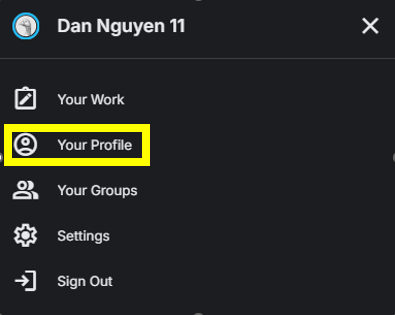

After that, the Kaggle name can be found similar to the one in the picture:

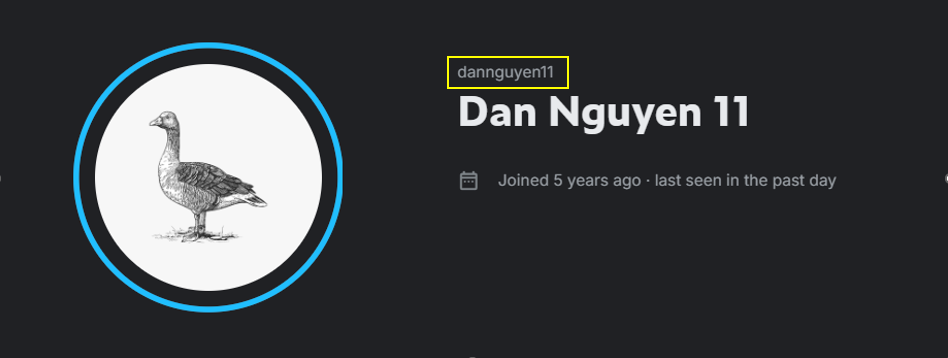

Please note that the name to be recorded is not "Dan Nguyen 11" but "dannguyen11". Marks will be deducted if you record the incorrect names.

Please also enter your details in this [google form](https://forms.gle/M5F3RERccoM7MuYE9).

# Part 1 Regression (50 Marks)

A few thousand people were questioned in a life and wellbeing survey to build a model to predict happiness of an individual. You need to build regression models to optimally predict the variable in the survey dataset called 'happiness' based on any, or all, of the other survey question responses. 

You have been provided with two datasets, ```regression_train.csv``` and ```regression_test.csv```. Using these datasets, you hope to build a model that can predict happiness level using the other variables. ```regression_train.csv``` comes with the ground-truth target label (i.e. happiness level) whereas `regression_test.csv` comes with independent variables (input information) only.

On the order of around 70 survey questions have been converted into predictor variables that can be used to predict happiness. We do not list all the predictor names here, but their names given in the data header can clearly be linked to the survey questions. e.g., the predictor variable 'iDontFeelParticularlyPleasedWithTheWayIAm' corresponds to the survey question 'I don’t feel particularly pleased with the way I am.'

**PLEASE NOTE THAT THE USE OF LIBRARIES ARE PROHIBITED IN THESE QUESTIONS UNLESS STATED OTHERWISE, ANSWERS USING LIBRARIES WILL RECEIVE 0 MARKS**

## Question 1 (NO LIBRARIES ALLOWED) (4 Mark)
Please load the ```regression_train.csv``` and fit a [$\textbf{multiple linear regression model}$](https://en.wikipedia.org/wiki/Linear_regression) with 'happiness' being the target variable. According to the summary table, which predictors do you think are possibly associated with the target variable (use the significance level of 0.01), and which are the **Top 5** strongest predictors? Please write an R script to automatically fetch and print this information.

**NOTE**: Manually doing the above tasks will result in 0 marks.

In [1]:
# ANSWER BLOCK

regression_train <- read.csv("regression_train.csv")
regression_test <- read.csv("regression_test.csv")

full_model<- lm(happiness ~ ., data = regression_train)

sum_full_model<-summary(full_model)
sum_full_model

coefficients_table <- sum_full_model$coefficients
predictors_table <- coefficients_table[rownames(coefficients_table)!= "(Intercept)", , drop = FALSE]
significant_predictors <- predictors_table[predictors_table[, "Pr(>|t|)"] < 0.01, , drop = FALSE]

print(rownames(significant_predictors))

top5_strongest <- head(predictors_table[order(abs(predictors_table[, "t value"]), decreasing = TRUE), , drop = FALSE],5)

cat("Top 5 strongest predictors are :",rownames(top5_strongest))
top5_strongest


Call:
lm(formula = happiness ~ ., data = regression_train)

Residuals:
     Min       1Q   Median       3Q      Max 
-27.9439  -4.2430   0.4693   4.3861  21.7657 

Coefficients:
                                                                                             Estimate
(Intercept)                                                                                 -21.88359
genderMale                                                                                   -0.30236
genderOther                                                                                  -1.00174
income10k - 15k                                                                               6.28585
income120k - 150k                                                                            11.47689
income150k - 200k                                                                            11.45754
income15k - 20k                                                                              15.40746
incom

 [1] "income10k - 15k"                                     
 [2] "income120k - 150k"                                   
 [3] "income150k - 200k"                                   
 [4] "income15k - 20k"                                     
 [5] "income200k above"                                    
 [6] "income20k - 50k"                                     
 [7] "income50k - 80k"                                     
 [8] "income80k - 120k"                                    
 [9] "whatIsYourHeightExpressItAsANumberInMetresM180 - 185"
[10] "alwaysStressed"                                      
Top 5 strongest predictors are : income80k - 120k income50k - 80k income200k above income20k - 50k income15k - 20k

,Estimate,Std. Error,t value,Pr(>|t|)
income80k - 120k,37.28064,1.660049,22.45755,1.419507e-74
income50k - 80k,28.70233,1.742010,16.47656,1.115904e-47
income200k above,20.03062,1.382642,14.48721,4.777672e-39
income20k - 50k,20.81995,1.587546,13.11455,2.606555e-33
income15k - 20k,15.40746,1.284859,11.99156,8.481388e-29


A full multiple linear regression model was fitted using happiness as the response variable and all other variables as predictors. Following the tutorial approach, I used summary(full_model) to inspect the coefficient table, p-values, and significance stars. Predictors with p-values smaller than 0.01 were automatically selected as variables possibly associated with happiness. The top five strongest predictors were ranked by the absolute value of their t-statistics.

## Question 2 (2 Mark)
[**R squared**](https://en.wikipedia.org/wiki/Coefficient_of_determination) from the summary table reflects that the full model doesn't fit the training dataset well; thus, you try to quantify the error between the values of the ground-truth and those of the model prediction. You want to write a function to predict 'happiness' with the given dataset and calculate the [root mean squared error (rMSE)](https://en.wikipedia.org/wiki/Root-mean-square_deviation) between the model predictions and the ground truths. Please test this function on the full model and the training dataset.

In [2]:
# ANSWER BLOCK
regression_train <- read.csv("regression_train.csv")
regression_test <- read.csv("regression_test.csv")

full_model<- lm(happiness ~ ., data = regression_train)

rMSE <- function(prediction,truth){sqrt(mean((truth - prediction)^2))}

full_model_predictions <- predict(full_model, regression_train)
full_model_rMSE <- rMSE(full_model_predictions, regression_train$happiness)

cat("The training rMSE of the full model is:",full_model_rMSE)

The training rMSE of the full model is: 6.701688

The rMSE function first calculates the squared difference between the observed happiness values and the predicted values, then takes the mean and square root. The full multiple linear regression model was used to predict happiness on the training data, and the rMSE was calculated by comparing these predictions with the true happiness values.

## Question 3 (2 Marks)
You find the full model complicated and try to reduce the complexity by performing [bidirectional stepwise regression](https://en.wikipedia.org/wiki/Stepwise_regression) with [BIC](https://en.wikipedia.org/wiki/Bayesian_information_criterion).

Calculate the **rMSE** of this new model with the function that you implemented previously. Is there anything you find unusual? Explain your findings in 100 words.

In [3]:
# ANSWER BLOCK
regression_train <- read.csv("regression_train.csv")
regression_test <- read.csv("regression_test.csv")

full_model<- lm(happiness ~ ., data = regression_train)

rMSE <- function(prediction,truth){sqrt(mean((truth - prediction)^2))}

full_model_predictions <- predict(full_model, regression_train)
full_model_rMSE <- rMSE(full_model_predictions, regression_train$happiness)
cat("The training rMSE of the full model is:",full_model_rMSE,"\n")
cat("Number of predictors in the full model:", length(coef(full_model)) - 1,"\n","\n")

bic_model<-step(full_model, trace = 0, k = log(nrow(regression_train)), direction = "both")
bic_model_predictions <- predict(bic_model, regression_train)
bic_model_rMSE <- rMSE(bic_model_predictions, regression_train$happiness)
cat("The training rMSE of the bic model is:",bic_model_rMSE,"\n")
cat("Number of predictors in the bic model:", length(coef(bic_model)) - 1)

The training rMSE of the full model is: 6.701688 
Number of predictors in the full model: 67 
 
The training rMSE of the bic model is: 7.330305 
Number of predictors in the bic model: 14

The unusual finding is that the BIC model has a higher training rMSE than the full model. The full model has a training rMSE of 6.701688, while the BIC model has a training rMSE of 7.330305. BIC does not only focus on reducing training error rMSE. It also reduces model complexity. Some predictors are removed even if they slightly improve the training fit. Therefore, the BIC model is simpler with only 14 predictors, compared to the 67 predictors of the full model, but this can also lead to a higher training rMSE.

## Question 4 (2 Mark)
Although stepwise regression has reduced the model complexity significantly, the model still contains a lot of variables that we want to remove. Therefore, you are interested in lightweight linear regression models with ONLY TWO predictors. Write a script to automatically find the best lightweight model which corresponds to the model with the least **rMSE** on the training dataset. Compare the **rMSE** of the best lightweight model with the **rMSE** of the full model - ```lm.fit``` - that you built previously. Give an explanation for these results based on consideration of the predictors involved.

In [4]:
# ANSWER BLOCK
regression_train <- read.csv("regression_train.csv")
regression_test <- read.csv("regression_test.csv")

full_model<- lm(happiness ~ ., data = regression_train)

rMSE <- function(prediction,truth){sqrt(mean((truth - prediction)^2))}

full_model_predictions <- predict(full_model, regression_train)
full_model_rMSE <- rMSE(full_model_predictions, regression_train$happiness)
cat("The training rMSE of the full model is:",full_model_rMSE,"\n")
cat("Number of predictors in the full model:", length(coef(full_model)) - 1,"\n","\n")

predictor_names <- names(regression_train)[names(regression_train)!= "happiness"]

two_predictor_combinations <- combn(predictor_names,2)

best_two_predictors_rMSE <- Inf
best_two_predictors_model <- NULL
best_two_predictors <- NULL

for (i in 1:ncol(two_predictor_combinations)){
    two_predictors<- two_predictor_combinations[,i]
    two_predictors_formula <- as.formula(paste("happiness ~",paste(two_predictors, collapse = "+")))
    two_predictors_model <- lm(two_predictors_formula, data = regression_train)
    two_predictors_result <- predict(two_predictors_model, regression_train)
    two_predictors_rMSE<- rMSE(two_predictors_result,regression_train$happiness) 

    if (two_predictors_rMSE < best_two_predictors_rMSE) {
        best_two_predictors_rMSE<-two_predictors_rMSE
        best_two_predictors_model<-two_predictors_model
        best_two_predictors<-two_predictors   
    }
}

cat("The best two predictors rMSE are:",best_two_predictors_rMSE,"\n")
cat("The best two predictors are:",best_two_predictors,"\n")
summary(best_two_predictors_model)

The training rMSE of the full model is: 6.701688 
Number of predictors in the full model: 67 
 
The best two predictors rMSE are: 7.885411 
The best two predictors are: income alwaysStressed 



Call:
lm(formula = two_predictors_formula, data = regression_train)

Residuals:
    Min      1Q  Median      3Q     Max 
-36.097  -5.068   0.050   5.502  24.288 

Coefficients:
                  Estimate Std. Error t value Pr(>|t|)    
(Intercept)       -12.9244     0.6116 -21.134  < 2e-16 ***
income10k - 15k     7.7152     1.2865   5.997 3.91e-09 ***
income120k - 150k  12.7052     1.2669  10.028  < 2e-16 ***
income150k - 200k  11.1911     1.2635   8.857  < 2e-16 ***
income15k - 20k    13.8703     1.2628  10.984  < 2e-16 ***
income200k above   20.4021     1.3996  14.577  < 2e-16 ***
income20k - 50k    22.5643     1.5631  14.435  < 2e-16 ***
income50k - 80k    28.8786     1.8088  15.966  < 2e-16 ***
income80k - 120k   36.9091     1.6307  22.634  < 2e-16 ***
alwaysStressed     -2.5286     0.2949  -8.576  < 2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 7.965 on 490 degrees of freedom
Multiple R-squared:  0.6767,	Adjusted R-squared:

### ANSWER (TEXT)
The best two-predictor model selected income and alwaysStressed, with a training rMSE of 7.885411. This is higher than the full model rMSE of 6.701688, which is expected because the full model uses many more predictors and can fit the training data more closely. However, the two-predictor model is much simpler and easier to interpret. The selected predictors also make sense, because income shows a strong positive association with happiness, while alwaysStressed has a negative coefficient. Therefore, this lightweight model sacrifices some training accuracy but still captures two important sources of variation in happiness.

## Question 5 (Libraries are allowed) (40 Marks)
As a Data Scientist, one of the key tasks is to build models $\textbf{most appropriate/closest}$ to the truth; thus, modelling will not be limited to the aforementioned steps in this assignment. To simulate for a realistic modelling process, this question will be in the form of a [Kaggle competition](https://www.kaggle.com/t/5a57b472c81e416cb6853ac62c422176) among students to find out who has the best model.

Thus, you **will be graded** by the **rMSE** performance of your model, the better your model, the higher your score. Additionally, you need to describe/document your thought process in this model building process, this is akin to showing your working properly for the mathematic sections. If you don't clearly document the reasonings behind the model you use, we will have to make some deductions on your scores.

This is the [video tutorial](https://www.youtube.com/results?search_query=how+to+join+a+kaggle+competition) on how to join any Kaggle competition. 

When you optimize your model's performance, you can use any supervised model that you know and feature selection might be a big help as well. [Check the non-exhaustive set of R functions relevant to this unit](https://docs.google.com/spreadsheets/d/1Np4Zd93k7JEMYo3OZkXExq-h5BIFnGt_bS84q8u4iiw/edit?usp=sharing) for ideas for different models to try.

$\textbf{Note}$ Please make sure that we can install the libraries that you use in this part, the code structure can be:

```install.packages("some package", repos='http://cran.us.r-project.org')```

```library("some package")```

Remember that if we cannot run your code, we will have to give you a deduction. Our suggestion is for you to use the standard ```R version 3.6.1```

You also need to name your final model ``fin.mod`` so we can run a check to find out your performance. A good test for your understanding would be to set the previous $\textbf{BIC model}$ to be the final model to check if your code works perfectly.

In [5]:
# Build your final model here, use additional coding blocks if you need to
regression_train <- read.csv("regression_train.csv")
regression_test <- read.csv("regression_test.csv")

set.seed(1)

rMSE <- function(prediction,truth){sqrt(mean((truth - prediction)^2))}

train_index <- sample(1:nrow(regression_train), floor(0.8*nrow(regression_train)))

local_train <- regression_train[train_index,]
local_test <- regression_train[-train_index,]

In [19]:
# =========================
# Q5 Stage 0: CV infrastructure
# =========================

set.seed(1)

regression_train <- read.csv("regression_train.csv")
regression_test <- read.csv("regression_test.csv")

rmse <- function(pred, truth) {
    sqrt(mean((truth - pred)^2))
}

# Align factor levels and numeric missing values between train and validation/test.
align_factor_levels_q5 <- function(train_data, new_data) {
    
    for (col_name in names(new_data)) {
        
        if (col_name %in% names(train_data)) {
            
            if (is.factor(train_data[[col_name]])) {
                
                temp <- as.character(new_data[[col_name]])
                temp[!(temp %in% levels(train_data[[col_name]]))] <- levels(train_data[[col_name]])[1]
                
                new_data[[col_name]] <- factor(
                    temp,
                    levels = levels(train_data[[col_name]])
                )
            }
            
            if (is.numeric(train_data[[col_name]])) {
                
                missing_id <- is.na(new_data[[col_name]])
                
                if (any(missing_id)) {
                    new_data[[col_name]][missing_id] <- median(
                        train_data[[col_name]],
                        na.rm = TRUE
                    )
                }
            }
        }
    }
    
    return(new_data)
}

# Generic repeated K-fold CV.
# fit_fn must take training raw data and return a fitted model object.
# predict_fn must take fitted model, validation raw data, and training raw data.
cv_eval <- function(data, fit_fn, predict_fn, k = 5, repeats = 2, seed_base = 100) {
    
    out <- c()
    
    for (r in 1:repeats) {
        
        set.seed(seed_base + r)
        folds <- sample(rep(1:k, length.out = nrow(data)))
        
        for (f in 1:k) {
            
            tr <- data[folds != f, ]
            va <- data[folds == f, ]
            
            mod <- fit_fn(tr)
            pred <- predict_fn(mod, va, tr)
            
            out <- c(out, rmse(pred, va$happiness))
            
            cat("repeat", r, "fold", f, "rMSE =", tail(out, 1), "\n")
        }
    }
    
    return(list(
        mean = mean(out),
        sd = sd(out),
        all = out
    ))
}

# Store all experiment results in one table.
experiment_results <- data.frame(
    stage = character(),
    model = character(),
    description = character(),
    cv_mean = numeric(),
    cv_sd = numeric(),
    stringsAsFactors = FALSE
)

add_result <- function(stage, model, description, cv_object) {
    
    new_row <- data.frame(
        stage = stage,
        model = model,
        description = description,
        cv_mean = cv_object$mean,
        cv_sd = cv_object$sd,
        stringsAsFactors = FALSE
    )
    
    return(rbind(experiment_results, new_row))
}

In [20]:
# =========================
# Q5 Stage 0: Baseline models
# =========================

# -------------------------
# Baseline 1: predict training mean
# -------------------------

fit_mean_model <- function(train) {
    return(list(mean_y = mean(train$happiness)))
}

predict_mean_model <- function(mod, valid, train) {
    return(rep(mod$mean_y, nrow(valid)))
}

cv_mean_baseline <- cv_eval(
    data = regression_train,
    fit_fn = fit_mean_model,
    predict_fn = predict_mean_model,
    k = 5,
    repeats = 2,
    seed_base = 100
)

experiment_results <- add_result(
    stage = "Stage 0",
    model = "Mean baseline",
    description = "Predict the training mean in each fold.",
    cv_object = cv_mean_baseline
)

# -------------------------
# Feature function: factor only
# -------------------------
# This follows Approach 1 from Ed:
# character categorical variables are converted to factors,
# and lm() automatically creates dummy variables.

make_features_factor_only <- function(data) {
    
    data2 <- data
    
    for (col_name in names(data2)) {
        if (is.character(data2[[col_name]])) {
            data2[[col_name]] <- as.factor(data2[[col_name]])
        }
    }
    
    return(data2)
}

# -------------------------
# Baseline 2: BIC LM with factor variables only
# -------------------------

fit_bic_factor_only <- function(train) {
    
    train_fe <- make_features_factor_only(train)
    
    full_mod <- lm(happiness ~ ., data = train_fe)
    
    bic_mod <- step(
        full_mod,
        trace = 0,
        k = log(nrow(train_fe)),
        direction = "both"
    )
    
    return(list(
        model = bic_mod,
        train_template = train_fe
    ))
}

predict_bic_factor_only <- function(mod, valid, train) {
    
    valid_fe <- make_features_factor_only(valid)
    valid_fe <- align_factor_levels_q5(mod$train_template, valid_fe)
    
    pred <- as.numeric(predict(mod$model, newdata = valid_fe))
    
    pred[is.na(pred)] <- mean(mod$train_template$happiness, na.rm = TRUE)
    
    return(pred)
}

cv_bic_factor_only <- cv_eval(
    data = regression_train,
    fit_fn = fit_bic_factor_only,
    predict_fn = predict_bic_factor_only,
    k = 5,
    repeats = 2,
    seed_base = 200
)

experiment_results <- add_result(
    stage = "Stage 0",
    model = "BIC LM factor only",
    description = "Categorical variables are treated as factors; no manual ordinal income encoding.",
    cv_object = cv_bic_factor_only
)

experiment_results

repeat 1 fold 1 rMSE = 14.72785 
repeat 1 fold 2 rMSE = 12.71242 
repeat 1 fold 3 rMSE = 14.09238 
repeat 1 fold 4 rMSE = 14.59251 
repeat 1 fold 5 rMSE = 13.20161 
repeat 2 fold 1 rMSE = 12.83458 
repeat 2 fold 2 rMSE = 14.52711 
repeat 2 fold 3 rMSE = 14.0843 
repeat 2 fold 4 rMSE = 14.0296 
repeat 2 fold 5 rMSE = 13.9065 
repeat 1 fold 1 rMSE = 8.080613 
repeat 1 fold 2 rMSE = 8.451703 
repeat 1 fold 3 rMSE = 7.440861 
repeat 1 fold 4 rMSE = 8.11205 
repeat 1 fold 5 rMSE = 7.454311 
repeat 2 fold 1 rMSE = 7.85616 
repeat 2 fold 2 rMSE = 8.048604 
repeat 2 fold 3 rMSE = 7.910334 
repeat 2 fold 4 rMSE = 8.15318 
repeat 2 fold 5 rMSE = 7.848359 


stage,model,description,cv_mean,cv_sd
<chr>,<chr>,<chr>,<dbl>,<dbl>
Stage 0,Mean baseline,Predict the training mean in each fold.,13.870886,0.7203973
Stage 0,BIC LM factor only,Categorical variables are treated as factors; no manual ordinal income encoding.,7.935617,0.3108416


In [21]:
# =========================
# Q5 Stage 1: Feature engineering versions for ablation
# =========================

make_features_q5 <- function(data, version = "factor_only") {
    
    data2 <- data
    
    if (version == "old_income_ord") {
        
        # Previous style: income is still kept as factor later,
        # but additional ordinal income features are added.
        income_levels <- c(
            "0 - 10k", "10k - 15k", "15k - 20k", "20k - 50k",
            "50k - 80k", "80k - 120k", "120k - 150k",
            "150k - 200k", "200k above"
        )
        
        height_levels <- c(
            "140 - 150", "150 - 155", "155 - 160", "160 - 165",
            "165 - 170", "170 - 175", "175 - 180", "180 - 185",
            "185 - 190", "190 above"
        )
        
        data2$income_ord <- as.numeric(
            factor(data2$income, levels = income_levels, ordered = TRUE)
        ) - 1
        
        data2$height_ord <- as.numeric(
            factor(
                data2$whatIsYourHeightExpressItAsANumberInMetresM,
                levels = height_levels,
                ordered = TRUE
            )
        ) - 1
    }
    
    if (version %in% c("old_income_ord", "no_income_ord", "factor_income_interaction")) {
        
        positive_vars <- c(
            "alwaysCalm",
            "alwaysHaveFun",
            "alwaysLoveAndCareForYourself",
            "iFindMostThingsAmusing",
            "iAmWellSatisfiedAboutEverythingInMyLife",
            "iFindBeautyInSomeThings",
            "iAlwaysHaveACheerfulEffectOnOthers",
            "iUsuallyHaveAGoodInfluenceOnEvents",
            "alwaysMakingProgress",
            "iFeelThatLifeIsVeryRewarding",
            "iHaveVeryWarmFeelingsTowardsAlmostEveryone",
            "lifeIsGood",
            "iLaughALot"
        )
        
        negative_vars <- c(
            "alwaysStressed",
            "alwaysSerious",
            "alwaysDepressed",
            "iRarelyWakeUpFeelingRested",
            "iDoNotThinkThatTheWorldIsAGoodPlace",
            "iFeelThatIAmNotEspeciallyInControlOfMyLife",
            "iDontHaveFunWithOtherPeople",
            "iDontFeelParticularlyPleasedWithTheWayIAm",
            "iAmNotParticularlyOptimisticAboutTheFuture",
            "iDontThinkILookAttractive"
        )
        
        positive_vars <- intersect(positive_vars, names(data2))
        negative_vars <- intersect(negative_vars, names(data2))
        
        data2$positive_score <- rowMeans(data2[, positive_vars, drop = FALSE], na.rm = TRUE)
        data2$negative_score <- rowMeans(data2[, negative_vars, drop = FALSE], na.rm = TRUE)
        data2$wellbeing_balance <- data2$positive_score - data2$negative_score
        
        data2$stress_squared <- data2$alwaysStressed^2
        data2$depressed_squared <- data2$alwaysDepressed^2
        data2$life_good_squared <- data2$lifeIsGood^2
        data2$laugh_squared <- data2$iLaughALot^2
        
        data2$stress_depressed <- data2$alwaysStressed * data2$alwaysDepressed
        data2$stress_life_good <- data2$alwaysStressed * data2$lifeIsGood
        data2$depressed_life_good <- data2$alwaysDepressed * data2$lifeIsGood
    }
    
    if (version == "old_income_ord") {
        
        # These are the suspicious ordinal-income interactions.
        data2$income_stress <- data2$income_ord * data2$alwaysStressed
        data2$income_depressed <- data2$income_ord * data2$alwaysDepressed
        data2$income_balance <- data2$income_ord * data2$wellbeing_balance
    }
    
    # Convert categorical variables to factors at the end.
    for (col_name in names(data2)) {
        if (is.character(data2[[col_name]])) {
            data2[[col_name]] <- as.factor(data2[[col_name]])
        }
    }
    
    return(data2)
}

In [22]:
# =========================
# Q5 Stage 1: BIC LM feature ablation
# =========================

fit_bic_lm_version <- function(version_name, use_factor_income_interaction = FALSE) {
    
    force(version_name)
    force(use_factor_income_interaction)
    
    fit_fn <- function(train) {
        
        train_fe <- make_features_q5(train, version_name)
        
        if (use_factor_income_interaction) {
            
            base_terms <- setdiff(names(train_fe), "happiness")
            
            interaction_terms <- c()
            
            if (all(c("income", "alwaysStressed") %in% names(train_fe))) {
                interaction_terms <- c(interaction_terms, "income:alwaysStressed")
            }
            
            if (all(c("income", "alwaysDepressed") %in% names(train_fe))) {
                interaction_terms <- c(interaction_terms, "income:alwaysDepressed")
            }
            
            if (all(c("income", "wellbeing_balance") %in% names(train_fe))) {
                interaction_terms <- c(interaction_terms, "income:wellbeing_balance")
            }
            
            formula_text <- paste(
                "happiness ~",
                paste(c(base_terms, interaction_terms), collapse = " + ")
            )
            
            full_formula <- as.formula(formula_text)
            
        } else {
            
            full_formula <- happiness ~ .
        }
        
        full_mod <- lm(full_formula, data = train_fe)
        
        bic_mod <- step(
            full_mod,
            trace = 0,
            k = log(nrow(train_fe)),
            direction = "both"
        )
        
        return(list(
            model = bic_mod,
            train_template = train_fe,
            version = version_name
        ))
    }
    
    return(fit_fn)
}

predict_bic_lm_version <- function(mod, valid, train) {
    
    valid_fe <- make_features_q5(valid, mod$version)
    valid_fe <- align_factor_levels_q5(mod$train_template, valid_fe)
    
    pred <- as.numeric(predict(mod$model, newdata = valid_fe))
    
    pred[is.na(pred)] <- mean(mod$train_template$happiness, na.rm = TRUE)
    
    return(pred)
}

# 1. Old feature style: includes income_ord and ordinal income interactions
cv_old_income_ord <- cv_eval(
    data = regression_train,
    fit_fn = fit_bic_lm_version("old_income_ord", FALSE),
    predict_fn = predict_bic_lm_version,
    k = 5,
    repeats = 2,
    seed_base = 300
)

experiment_results <- add_result(
    stage = "Stage 1",
    model = "BIC LM old income_ord",
    description = "Previous-style engineered features with income_ord and ordinal-income interactions.",
    cv_object = cv_old_income_ord
)

# 2. Remove income_ord / height_ord / income ordinal interactions
cv_no_income_ord <- cv_eval(
    data = regression_train,
    fit_fn = fit_bic_lm_version("no_income_ord", FALSE),
    predict_fn = predict_bic_lm_version,
    k = 5,
    repeats = 2,
    seed_base = 400
)

experiment_results <- add_result(
    stage = "Stage 1",
    model = "BIC LM no income_ord",
    description = "Remove income_ord, height_ord, income_stress, income_depressed, and income_balance; keep income as factor.",
    cv_object = cv_no_income_ord
)

# 3. Use factor income interactions instead of income_ord interactions
cv_factor_income_interaction <- cv_eval(
    data = regression_train,
    fit_fn = fit_bic_lm_version("factor_income_interaction", TRUE),
    predict_fn = predict_bic_lm_version,
    k = 5,
    repeats = 2,
    seed_base = 500
)

experiment_results <- add_result(
    stage = "Stage 1",
    model = "BIC LM factor income interaction",
    description = "Keep income as factor and add income:stress, income:depressed, income:wellbeing_balance interactions.",
    cv_object = cv_factor_income_interaction
)

experiment_results[order(experiment_results$cv_mean), ]

repeat 1 fold 1 rMSE = 7.820566 
repeat 1 fold 2 rMSE = 6.847956 
repeat 1 fold 3 rMSE = 7.676026 
repeat 1 fold 4 rMSE = 7.694151 
repeat 1 fold 5 rMSE = 8.146738 
repeat 2 fold 1 rMSE = 7.197236 
repeat 2 fold 2 rMSE = 7.236462 
repeat 2 fold 3 rMSE = 7.987509 
repeat 2 fold 4 rMSE = 7.140891 
repeat 2 fold 5 rMSE = 7.507694 
repeat 1 fold 1 rMSE = 7.720317 
repeat 1 fold 2 rMSE = 7.97914 
repeat 1 fold 3 rMSE = 7.327319 
repeat 1 fold 4 rMSE = 7.679449 
repeat 1 fold 5 rMSE = 7.377263 
repeat 2 fold 1 rMSE = 8.06019 
repeat 2 fold 2 rMSE = 6.888439 
repeat 2 fold 3 rMSE = 7.06458 
repeat 2 fold 4 rMSE = 7.987207 
repeat 2 fold 5 rMSE = 8.218422 
repeat 1 fold 1 rMSE = 7.563496 
repeat 1 fold 2 rMSE = 7.727107 
repeat 1 fold 3 rMSE = 8.343267 
repeat 1 fold 4 rMSE = 6.765815 
repeat 1 fold 5 rMSE = 8.520064 
repeat 2 fold 1 rMSE = 8.266891 
repeat 2 fold 2 rMSE = 7.315441 
repeat 2 fold 3 rMSE = 7.25009 
repeat 2 fold 4 rMSE = 8.357847 
repeat 2 fold 5 rMSE = 7.128404 


,stage,model,description,cv_mean,cv_sd
,<chr>,<chr>,<chr>,<dbl>,<dbl>
3,Stage 1,BIC LM old income_ord,Previous-style engineered features with income_ord and ordinal-income interactions.,7.525523,0.4131399
4,Stage 1,BIC LM no income_ord,"Remove income_ord, height_ord, income_stress, income_depressed, and income_balance; keep income as factor.",7.630233,0.4492595
5,Stage 1,BIC LM factor income interaction,"Keep income as factor and add income:stress, income:depressed, income:wellbeing_balance interactions.",7.723842,0.6149829
2,Stage 0,BIC LM factor only,Categorical variables are treated as factors; no manual ordinal income encoding.,7.935617,0.3108416
1,Stage 0,Mean baseline,Predict the training mean in each fold.,13.870886,0.7203973


# Stage 1 conclusion:
# Removing income_ord and its interaction terms did not improve BIC LM CV performance.
# The previous feature version with income_ord had the lowest CV mean among the tested LM variants.
# Therefore, I keep old_income_ord as the current feature baseline, but still test no_income_ord in GBM because tree models may react differently.

In [23]:
# =========================
# Q5 Stage 2: GBM model comparison on different feature versions
# =========================

if (!requireNamespace("gbm", quietly = TRUE)) {
    install.packages("gbm", repos = "https://cloud.r-project.org")
}

library(gbm)

# -------------------------
# 1. GBM fit / predict wrappers
# -------------------------

fit_gbm_version <- function(version_name,
                            n.trees_value,
                            depth_value,
                            shrinkage_value,
                            minobs_value,
                            bag_value,
                            seed_value,
                            inner_cv_folds = 3) {
    
    force(version_name)
    force(n.trees_value)
    force(depth_value)
    force(shrinkage_value)
    force(minobs_value)
    force(bag_value)
    force(seed_value)
    force(inner_cv_folds)
    
    fit_fn <- function(train) {
        
        train_fe <- make_features_q5(train, version_name)
        
        set.seed(seed_value)
        
        mod <- gbm(
            happiness ~ .,
            data = train_fe,
            distribution = "gaussian",
            n.trees = n.trees_value,
            interaction.depth = depth_value,
            shrinkage = shrinkage_value,
            n.minobsinnode = minobs_value,
            bag.fraction = bag_value,
            cv.folds = inner_cv_folds,
            verbose = FALSE
        )
        
        best_trees <- suppressWarnings(
            gbm.perf(mod, method = "cv", plot.it = FALSE)
        )
        
        if (is.null(best_trees) || is.na(best_trees) || best_trees < 10) {
            best_trees <- n.trees_value
        }
        
        return(list(
            model = mod,
            train_template = train_fe,
            version = version_name,
            best_trees = best_trees
        ))
    }
    
    return(fit_fn)
}

predict_gbm_version <- function(mod, valid, train) {
    
    valid_fe <- make_features_q5(valid, mod$version)
    valid_fe <- align_factor_levels_q5(mod$train_template, valid_fe)
    
    pred <- as.numeric(
        predict(
            mod$model,
            newdata = valid_fe,
            n.trees = mod$best_trees
        )
    )
    
    pred[is.na(pred)] <- mean(mod$train_template$happiness, na.rm = TRUE)
    
    return(pred)
}

# -------------------------
# 2. Small GBM grid
# -------------------------
# This is a first-pass grid. Use repeats = 1 first to avoid very long runtime.
# After finding the best few configs, rerun them with more repeats.

gbm_grid_stage2 <- data.frame(
    feature_version = rep(c("old_income_ord", "no_income_ord"), each = 4),
    config_name = rep(c("depth2_slow", "depth2_mid", "depth3_mid", "depth4_fast"), times = 2),
    n.trees = rep(c(1200, 900, 800, 700), times = 2),
    depth = rep(c(2, 2, 3, 4), times = 2),
    shrinkage = rep(c(0.012, 0.018, 0.018, 0.018), times = 2),
    n.minobsinnode = rep(c(15, 10, 10, 8), times = 2),
    bag.fraction = rep(c(0.65, 0.65, 0.60, 0.60), times = 2),
    stringsAsFactors = FALSE
)

gbm_stage2_results <- data.frame(
    stage = character(),
    model = character(),
    description = character(),
    feature_version = character(),
    config_name = character(),
    n.trees = numeric(),
    depth = numeric(),
    shrinkage = numeric(),
    n.minobsinnode = numeric(),
    bag.fraction = numeric(),
    cv_mean = numeric(),
    cv_sd = numeric(),
    stringsAsFactors = FALSE
)

# -------------------------
# 3. Run Stage 2 GBM CV
# -------------------------

for (i in seq_len(nrow(gbm_grid_stage2))) {
    
    current_row <- gbm_grid_stage2[i, ]
    
    cat("\nRunning GBM Stage 2 config", i, "of", nrow(gbm_grid_stage2), "\n")
    print(current_row)
    
    fit_fn_current <- fit_gbm_version(
        version_name = current_row$feature_version,
        n.trees_value = current_row$n.trees,
        depth_value = current_row$depth,
        shrinkage_value = current_row$shrinkage,
        minobs_value = current_row$n.minobsinnode,
        bag_value = current_row$bag.fraction,
        seed_value = 700 + i,
        inner_cv_folds = 3
    )
    
    cv_current <- cv_eval(
        data = regression_train,
        fit_fn = fit_fn_current,
        predict_fn = predict_gbm_version,
        k = 5,
        repeats = 1,
        seed_base = 700 + i
    )
    
    gbm_stage2_results <- rbind(
        gbm_stage2_results,
        data.frame(
            stage = "Stage 2",
            model = "GBM",
            description = "GBM with inner CV selected n.trees.",
            feature_version = current_row$feature_version,
            config_name = current_row$config_name,
            n.trees = current_row$n.trees,
            depth = current_row$depth,
            shrinkage = current_row$shrinkage,
            n.minobsinnode = current_row$n.minobsinnode,
            bag.fraction = current_row$bag.fraction,
            cv_mean = cv_current$mean,
            cv_sd = cv_current$sd,
            stringsAsFactors = FALSE
        )
    )
    
    experiment_results <- rbind(
        experiment_results,
        data.frame(
            stage = "Stage 2",
            model = paste0("GBM ", current_row$feature_version, " ", current_row$config_name),
            description = paste(
                "GBM using feature version", current_row$feature_version,
                "with depth", current_row$depth,
                "and shrinkage", current_row$shrinkage
            ),
            cv_mean = cv_current$mean,
            cv_sd = cv_current$sd,
            stringsAsFactors = FALSE
        )
    )
}

cat("\nStage 2 GBM results:\n")
print(gbm_stage2_results[order(gbm_stage2_results$cv_mean), ])

cat("\nAll experiment results so far:\n")
print(experiment_results[order(experiment_results$cv_mean), ])


Running GBM Stage 2 config 1 of 8 
  feature_version config_name n.trees depth shrinkage n.minobsinnode
1  old_income_ord depth2_slow    1200     2     0.012             15
  bag.fraction
1         0.65
repeat 1 fold 1 rMSE = 6.832305 
repeat 1 fold 2 rMSE = 6.958767 
repeat 1 fold 3 rMSE = 8.531198 
repeat 1 fold 4 rMSE = 6.632279 
repeat 1 fold 5 rMSE = 6.620753 

Running GBM Stage 2 config 2 of 8 
  feature_version config_name n.trees depth shrinkage n.minobsinnode
2  old_income_ord  depth2_mid     900     2     0.018             10
  bag.fraction
2         0.65
repeat 1 fold 1 rMSE = 7.600745 
repeat 1 fold 2 rMSE = 7.742751 
repeat 1 fold 3 rMSE = 6.722949 
repeat 1 fold 4 rMSE = 6.972324 
repeat 1 fold 5 rMSE = 7.213728 

Running GBM Stage 2 config 3 of 8 
  feature_version config_name n.trees depth shrinkage n.minobsinnode
3  old_income_ord  depth3_mid     800     3     0.018             10
  bag.fraction
3          0.6
repeat 1 fold 1 rMSE = 7.726568 
repeat 1 fold 2 rMSE = 6.

In [24]:
# =========================
# Q5 Stage 2b: Confirm the best GBM configurations with repeated CV
# =========================

# Select the top configurations from Stage 2 first-pass results.
top_gbm_configs <- gbm_stage2_results[order(gbm_stage2_results$cv_mean), ][1:4, ]

cat("Top GBM configs to confirm:\n")
print(top_gbm_configs)

gbm_stage2b_results <- data.frame(
    stage = character(),
    model = character(),
    description = character(),
    feature_version = character(),
    config_name = character(),
    n.trees = numeric(),
    depth = numeric(),
    shrinkage = numeric(),
    n.minobsinnode = numeric(),
    bag.fraction = numeric(),
    cv_mean = numeric(),
    cv_sd = numeric(),
    stringsAsFactors = FALSE
)

for (i in seq_len(nrow(top_gbm_configs))) {
    
    current_row <- top_gbm_configs[i, ]
    
    cat("\nConfirming GBM config", i, "of", nrow(top_gbm_configs), "\n")
    print(current_row)
    
    fit_fn_current <- fit_gbm_version(
        version_name = current_row$feature_version,
        n.trees_value = current_row$n.trees,
        depth_value = current_row$depth,
        shrinkage_value = current_row$shrinkage,
        minobs_value = current_row$n.minobsinnode,
        bag_value = current_row$bag.fraction,
        seed_value = 900 + i,
        inner_cv_folds = 3
    )
    
    cv_current <- cv_eval(
        data = regression_train,
        fit_fn = fit_fn_current,
        predict_fn = predict_gbm_version,
        k = 5,
        repeats = 3,
        seed_base = 900 + i
    )
    
    gbm_stage2b_results <- rbind(
        gbm_stage2b_results,
        data.frame(
            stage = "Stage 2b",
            model = "GBM repeated CV",
            description = "Repeated CV confirmation of top Stage 2 GBM configurations.",
            feature_version = current_row$feature_version,
            config_name = current_row$config_name,
            n.trees = current_row$n.trees,
            depth = current_row$depth,
            shrinkage = current_row$shrinkage,
            n.minobsinnode = current_row$n.minobsinnode,
            bag.fraction = current_row$bag.fraction,
            cv_mean = cv_current$mean,
            cv_sd = cv_current$sd,
            stringsAsFactors = FALSE
        )
    )
    
    experiment_results <- rbind(
        experiment_results,
        data.frame(
            stage = "Stage 2b",
            model = paste0("Repeated GBM ", current_row$feature_version, " ", current_row$config_name),
            description = paste(
                "Repeated CV confirmation for",
                current_row$feature_version,
                current_row$config_name
            ),
            cv_mean = cv_current$mean,
            cv_sd = cv_current$sd,
            stringsAsFactors = FALSE
        )
    )
}

cat("\nStage 2b repeated GBM results:\n")
print(gbm_stage2b_results[order(gbm_stage2b_results$cv_mean), ])

cat("\nAll experiment results so far:\n")
print(experiment_results[order(experiment_results$cv_mean), ])

Top GBM configs to confirm:
    stage model                         description feature_version config_name
7 Stage 2   GBM GBM with inner CV selected n.trees.   no_income_ord  depth3_mid
4 Stage 2   GBM GBM with inner CV selected n.trees.  old_income_ord depth4_fast
8 Stage 2   GBM GBM with inner CV selected n.trees.   no_income_ord depth4_fast
6 Stage 2   GBM GBM with inner CV selected n.trees.   no_income_ord  depth2_mid
  n.trees depth shrinkage n.minobsinnode bag.fraction  cv_mean     cv_sd
7     800     3     0.018             10         0.60 7.002816 0.1589657
4     700     4     0.018              8         0.60 7.069361 0.4718221
8     700     4     0.018              8         0.60 7.097727 0.6718898
6     900     2     0.018             10         0.65 7.097975 0.3633988

Confirming GBM config 1 of 4 
    stage model                         description feature_version config_name
7 Stage 2   GBM GBM with inner CV selected n.trees.   no_income_ord  depth3_mid
  n.trees depth 

# Stage 2 conclusion:
# After repeated CV, no_income_ord depth2_mid gave the best mean CV rMSE.
# The differences between the top GBM models were small, but the best repeated result used no_income_ord.
# Therefore, I use no_income_ord as the GBM feature version and depth2_mid as the main GBM configuration for the next stage.

In [25]:
# =========================
# Q5 Stage 3: Two-stage income residual model
# Stage 1: lm(happiness ~ income)
# Stage 2: GBM fits residuals using other variables
# =========================

# -------------------------
# 1. Save current best single-stage GBM setting
# -------------------------

best_gbm_stage2b <- gbm_stage2b_results[order(gbm_stage2b_results$cv_mean), ][1, ]

cat("Current best repeated GBM from Stage 2b:\n")
print(best_gbm_stage2b)

features_v2_gbm <- best_gbm_stage2b$feature_version

# -------------------------
# 2. Helper for income-only stage 1
# -------------------------

make_income_only <- function(data) {
    
    data2 <- data[, intersect(c("happiness", "income"), names(data)), drop = FALSE]
    
    if ("income" %in% names(data2)) {
        if (is.character(data2$income)) {
            data2$income <- as.factor(data2$income)
        }
    }
    
    return(data2)
}

# -------------------------
# 3. Two-stage fit function generator
# -------------------------

fit_two_stage_income_gbm <- function(feature_version,
                                     n.trees_value,
                                     depth_value,
                                     shrinkage_value,
                                     minobs_value,
                                     bag_value,
                                     seed_value,
                                     inner_cv_folds = 3) {
    
    force(feature_version)
    force(n.trees_value)
    force(depth_value)
    force(shrinkage_value)
    force(minobs_value)
    force(bag_value)
    force(seed_value)
    force(inner_cv_folds)
    
    fit_fn <- function(train) {
        
        # Stage 1: income-only LM
        train_income <- make_income_only(train)
        
        stage1 <- lm(
            happiness ~ income,
            data = train_income
        )
        
        stage1_pred_train <- as.numeric(
            predict(stage1, newdata = train_income)
        )
        
        resid1 <- train$happiness - stage1_pred_train
        
        # Stage 2: GBM on residuals using non-income features
        stage2_data <- make_features_q5(train, feature_version)
        
        # Remove original target and income to avoid directly repeating stage 1.
        if ("happiness" %in% names(stage2_data)) {
            stage2_data$happiness <- NULL
        }
        
        if ("income" %in% names(stage2_data)) {
            stage2_data$income <- NULL
        }
        
        stage2_data$resid1 <- resid1
        
        set.seed(seed_value)
        
        stage2 <- gbm(
            resid1 ~ .,
            data = stage2_data,
            distribution = "gaussian",
            n.trees = n.trees_value,
            interaction.depth = depth_value,
            shrinkage = shrinkage_value,
            n.minobsinnode = minobs_value,
            bag.fraction = bag_value,
            cv.folds = inner_cv_folds,
            verbose = FALSE
        )
        
        best_trees <- suppressWarnings(
            gbm.perf(stage2, method = "cv", plot.it = FALSE)
        )
        
        if (is.null(best_trees) || is.na(best_trees) || best_trees < 10) {
            best_trees <- n.trees_value
        }
        
        return(list(
            stage1 = stage1,
            stage1_template = train_income,
            stage2 = stage2,
            stage2_template = stage2_data,
            feature_version = feature_version,
            best_trees = best_trees
        ))
    }
    
    return(fit_fn)
}

# -------------------------
# 4. Two-stage predict function
# -------------------------

predict_two_stage_income_gbm <- function(mod, valid, train) {
    
    # Stage 1 prediction
    valid_income <- make_income_only(valid)
    
    # Remove happiness from validation newdata if present
    if ("happiness" %in% names(valid_income)) {
        valid_income$happiness <- NULL
    }
    
    valid_income <- align_factor_levels_q5(
        mod$stage1_template,
        valid_income
    )
    
    p1 <- as.numeric(
        predict(mod$stage1, newdata = valid_income)
    )
    
    p1[is.na(p1)] <- mean(mod$stage1_template$happiness, na.rm = TRUE)
    
    # Stage 2 residual prediction
    valid_stage2 <- make_features_q5(valid, mod$feature_version)
    
    if ("happiness" %in% names(valid_stage2)) {
        valid_stage2$happiness <- NULL
    }
    
    if ("income" %in% names(valid_stage2)) {
        valid_stage2$income <- NULL
    }
    
    valid_stage2 <- align_factor_levels_q5(
        mod$stage2_template,
        valid_stage2
    )
    
    p2 <- as.numeric(
        predict(
            mod$stage2,
            newdata = valid_stage2,
            n.trees = mod$best_trees
        )
    )
    
    p2[is.na(p2)] <- 0
    
    return(p1 + p2)
}

# -------------------------
# 5. Test a small two-stage grid
# -------------------------

two_stage_grid <- data.frame(
    feature_version = c("no_income_ord", "no_income_ord", "no_income_ord", "old_income_ord"),
    config_name = c("resid_depth2_mid", "resid_depth3_mid", "resid_depth4_fast", "resid_old_depth4_fast"),
    n.trees = c(900, 800, 700, 700),
    depth = c(2, 3, 4, 4),
    shrinkage = c(0.018, 0.018, 0.018, 0.018),
    n.minobsinnode = c(10, 10, 8, 8),
    bag.fraction = c(0.65, 0.60, 0.60, 0.60),
    stringsAsFactors = FALSE
)

two_stage_results <- data.frame(
    stage = character(),
    model = character(),
    description = character(),
    feature_version = character(),
    config_name = character(),
    n.trees = numeric(),
    depth = numeric(),
    shrinkage = numeric(),
    n.minobsinnode = numeric(),
    bag.fraction = numeric(),
    cv_mean = numeric(),
    cv_sd = numeric(),
    stringsAsFactors = FALSE
)

for (i in seq_len(nrow(two_stage_grid))) {
    
    current_row <- two_stage_grid[i, ]
    
    cat("\nRunning two-stage config", i, "of", nrow(two_stage_grid), "\n")
    print(current_row)
    
    fit_fn_current <- fit_two_stage_income_gbm(
        feature_version = current_row$feature_version,
        n.trees_value = current_row$n.trees,
        depth_value = current_row$depth,
        shrinkage_value = current_row$shrinkage,
        minobs_value = current_row$n.minobsinnode,
        bag_value = current_row$bag.fraction,
        seed_value = 1200 + i,
        inner_cv_folds = 3
    )
    
    cv_current <- cv_eval(
        data = regression_train,
        fit_fn = fit_fn_current,
        predict_fn = predict_two_stage_income_gbm,
        k = 5,
        repeats = 2,
        seed_base = 1200 + i
    )
    
    two_stage_results <- rbind(
        two_stage_results,
        data.frame(
            stage = "Stage 3",
            model = "Two-stage income residual GBM",
            description = "Stage 1 uses lm(happiness ~ income); Stage 2 uses GBM to model residuals.",
            feature_version = current_row$feature_version,
            config_name = current_row$config_name,
            n.trees = current_row$n.trees,
            depth = current_row$depth,
            shrinkage = current_row$shrinkage,
            n.minobsinnode = current_row$n.minobsinnode,
            bag.fraction = current_row$bag.fraction,
            cv_mean = cv_current$mean,
            cv_sd = cv_current$sd,
            stringsAsFactors = FALSE
        )
    )
    
    experiment_results <- rbind(
        experiment_results,
        data.frame(
            stage = "Stage 3",
            model = paste0("Two-stage ", current_row$config_name),
            description = paste(
                "Income-only LM followed by residual GBM using",
                current_row$feature_version
            ),
            cv_mean = cv_current$mean,
            cv_sd = cv_current$sd,
            stringsAsFactors = FALSE
        )
    )
}

cat("\nStage 3 two-stage results:\n")
print(two_stage_results[order(two_stage_results$cv_mean), ])

cat("\nAll experiment results so far:\n")
print(experiment_results[order(experiment_results$cv_mean), ])

Current best repeated GBM from Stage 2b:
     stage           model
4 Stage 2b GBM repeated CV
                                                  description feature_version
4 Repeated CV confirmation of top Stage 2 GBM configurations.   no_income_ord
  config_name n.trees depth shrinkage n.minobsinnode bag.fraction  cv_mean
4  depth2_mid     900     2     0.018             10         0.65 7.081809
      cv_sd
4 0.4593468

Running two-stage config 1 of 4 
  feature_version      config_name n.trees depth shrinkage n.minobsinnode
1   no_income_ord resid_depth2_mid     900     2     0.018             10
  bag.fraction
1         0.65
repeat 1 fold 1 rMSE = 7.270656 
repeat 1 fold 2 rMSE = 8.405109 
repeat 1 fold 3 rMSE = 6.939271 
repeat 1 fold 4 rMSE = 6.792794 
repeat 1 fold 5 rMSE = 7.660493 
repeat 2 fold 1 rMSE = 6.994918 
repeat 2 fold 2 rMSE = 8.09267 
repeat 2 fold 3 rMSE = 6.748159 
repeat 2 fold 4 rMSE = 6.423603 
repeat 2 fold 5 rMSE = 7.496208 

Running two-stage config 2 of 4 


### Stage 4: Ensemble and blend testing

After Stage 3, the two-stage income residual model was not retained because it had higher repeated CV rMSE than the best single-stage GBM. I then tested whether blending the best candidates could improve performance. To make the comparison fair, all candidate models were evaluated on the same repeated CV splits, and their out-of-fold predictions were collected for correlation and blend-weight testing.

In [26]:
# =========================
# Q5 Stage 4: Same-fold OOF predictions and blend testing
# =========================

# -------------------------
# 1. Candidate models
# -------------------------
# Keep only models that were competitive or conceptually useful.
# Two-stage models are not included because Stage 3 CV was worse.

candidate_specs <- list(
    
    list(
        name = "BIC_old",
        fit_fn = fit_bic_lm_version("old_income_ord", FALSE),
        predict_fn = predict_bic_lm_version
    ),
    
    list(
        name = "GBM_no_depth2",
        fit_fn = fit_gbm_version(
            version_name = "no_income_ord",
            n.trees_value = 900,
            depth_value = 2,
            shrinkage_value = 0.018,
            minobs_value = 10,
            bag_value = 0.65,
            seed_value = 1601,
            inner_cv_folds = 3
        ),
        predict_fn = predict_gbm_version
    ),
    
    list(
        name = "GBM_no_depth4",
        fit_fn = fit_gbm_version(
            version_name = "no_income_ord",
            n.trees_value = 700,
            depth_value = 4,
            shrinkage_value = 0.018,
            minobs_value = 8,
            bag_value = 0.60,
            seed_value = 1602,
            inner_cv_folds = 3
        ),
        predict_fn = predict_gbm_version
    ),
    
    list(
        name = "GBM_old_depth4",
        fit_fn = fit_gbm_version(
            version_name = "old_income_ord",
            n.trees_value = 700,
            depth_value = 4,
            shrinkage_value = 0.018,
            minobs_value = 8,
            bag_value = 0.60,
            seed_value = 1603,
            inner_cv_folds = 3
        ),
        predict_fn = predict_gbm_version
    )
)

candidate_names <- sapply(candidate_specs, function(x) x$name)

print(candidate_names)

# -------------------------
# 2. Collect same-fold OOF predictions
# -------------------------

clip_by_row <- function(pred, low, high) {
    pmin(pmax(pred, low), high)
}

collect_oof_predictions <- function(data, candidate_specs, k = 5, repeats = 2, seed_base = 2000) {
    
    all_blocks <- list()
    block_id <- 1
    
    for (r in seq_len(repeats)) {
        
        set.seed(seed_base + r)
        folds <- sample(rep(1:k, length.out = nrow(data)))
        
        for (f in seq_len(k)) {
            
            cat("\nStage 4 repeat", r, "fold", f, "\n")
            
            train_index <- which(folds != f)
            valid_index <- which(folds == f)
            
            tr <- data[train_index, ]
            va <- data[valid_index, ]
            
            pred_block <- data.frame(
                row_id = valid_index,
                repeat_id = r,
                fold_id = f,
                truth = va$happiness,
                clip_low = as.numeric(quantile(tr$happiness, 0.01, na.rm = TRUE)),
                clip_high = as.numeric(quantile(tr$happiness, 0.99, na.rm = TRUE))
            )
            
            for (j in seq_along(candidate_specs)) {
                
                cand <- candidate_specs[[j]]
                
                cat("  Fitting candidate:", cand$name, "\n")
                
                mod <- cand$fit_fn(tr)
                pred <- cand$predict_fn(mod, va, tr)
                
                pred[is.na(pred)] <- mean(tr$happiness, na.rm = TRUE)
                
                pred_block[[cand$name]] <- as.numeric(pred)
            }
            
            all_blocks[[block_id]] <- pred_block
            block_id <- block_id + 1
        }
    }
    
    return(do.call(rbind, all_blocks))
}

# Use repeats = 2 first. If runtime is acceptable and final decision is close,
# rerun this with repeats = 3.
oof_long <- collect_oof_predictions(
    data = regression_train,
    candidate_specs = candidate_specs,
    k = 5,
    repeats = 2,
    seed_base = 2200
)

head(oof_long)

# -------------------------
# 3. Evaluate single candidate models on the same folds
# -------------------------

calc_cv_summary <- function(pred, truth, repeat_id) {
    
    pooled_rmse <- rmse(pred, truth)
    
    repeat_rmse <- tapply(
        seq_along(pred),
        repeat_id,
        function(idx) rmse(pred[idx], truth[idx])
    )
    
    return(c(
        cv_mean = mean(repeat_rmse),
        cv_sd = sd(repeat_rmse),
        pooled_rmse = pooled_rmse
    ))
}

single_model_cv <- data.frame(
    model = character(),
    clip_method = character(),
    cv_mean = numeric(),
    cv_sd = numeric(),
    pooled_rmse = numeric(),
    stringsAsFactors = FALSE
)

for (model_name in candidate_names) {
    
    pred_raw <- oof_long[[model_name]]
    
    raw_summary <- calc_cv_summary(
        pred = pred_raw,
        truth = oof_long$truth,
        repeat_id = oof_long$repeat_id
    )
    
    single_model_cv <- rbind(
        single_model_cv,
        data.frame(
            model = model_name,
            clip_method = "none",
            cv_mean = raw_summary["cv_mean"],
            cv_sd = raw_summary["cv_sd"],
            pooled_rmse = raw_summary["pooled_rmse"],
            stringsAsFactors = FALSE
        )
    )
    
    pred_clip <- clip_by_row(
        pred = pred_raw,
        low = oof_long$clip_low,
        high = oof_long$clip_high
    )
    
    clip_summary <- calc_cv_summary(
        pred = pred_clip,
        truth = oof_long$truth,
        repeat_id = oof_long$repeat_id
    )
    
    single_model_cv <- rbind(
        single_model_cv,
        data.frame(
            model = model_name,
            clip_method = "q01_q99",
            cv_mean = clip_summary["cv_mean"],
            cv_sd = clip_summary["cv_sd"],
            pooled_rmse = clip_summary["pooled_rmse"],
            stringsAsFactors = FALSE
        )
    )
}

cat("\nSingle model same-fold CV results:\n")
print(single_model_cv[order(single_model_cv$cv_mean), ])

# -------------------------
# 4. Prediction correlation
# -------------------------
# If models are too highly correlated, blend may not help much.

candidate_correlations <- cor(
    oof_long[, candidate_names],
    use = "pairwise.complete.obs"
)

cat("\nCandidate prediction correlations:\n")
print(candidate_correlations)

# -------------------------
# 5. Grid-search non-negative blend weights
# -------------------------
# Use the top 3 single models by same-fold CV.

top_models_for_blend <- single_model_cv[
    single_model_cv$clip_method == "q01_q99",
]

top_models_for_blend <- top_models_for_blend[
    order(top_models_for_blend$cv_mean),
]

top_names <- top_models_for_blend$model[1:3]

cat("\nTop models selected for blend:\n")
print(top_names)

weight_grid <- seq(0, 1, by = 0.05)

blend_results <- data.frame(
    model_1 = character(),
    model_2 = character(),
    model_3 = character(),
    w1 = numeric(),
    w2 = numeric(),
    w3 = numeric(),
    clip_method = character(),
    cv_mean = numeric(),
    cv_sd = numeric(),
    pooled_rmse = numeric(),
    stringsAsFactors = FALSE
)

for (w1 in weight_grid) {
    
    for (w2 in weight_grid) {
        
        w3 <- 1 - w1 - w2
        
        if (w3 < -1e-8) {
            next
        }
        
        weights <- c(w1, w2, w3)
        
        pred_blend_raw <- as.numeric(
            as.matrix(oof_long[, top_names]) %*% weights
        )
        
        for (clip_method in c("none", "q01_q99")) {
            
            if (clip_method == "q01_q99") {
                pred_blend <- clip_by_row(
                    pred = pred_blend_raw,
                    low = oof_long$clip_low,
                    high = oof_long$clip_high
                )
            } else {
                pred_blend <- pred_blend_raw
            }
            
            blend_summary <- calc_cv_summary(
                pred = pred_blend,
                truth = oof_long$truth,
                repeat_id = oof_long$repeat_id
            )
            
            blend_results <- rbind(
                blend_results,
                data.frame(
                    model_1 = top_names[1],
                    model_2 = top_names[2],
                    model_3 = top_names[3],
                    w1 = w1,
                    w2 = w2,
                    w3 = w3,
                    clip_method = clip_method,
                    cv_mean = blend_summary["cv_mean"],
                    cv_sd = blend_summary["cv_sd"],
                    pooled_rmse = blend_summary["pooled_rmse"],
                    stringsAsFactors = FALSE
                )
            )
        }
    }
}

blend_results <- blend_results[order(blend_results$cv_mean), ]

cat("\nTop blend results:\n")
print(head(blend_results, 20))

# -------------------------
# 6. Add the best blend to experiment_results
# -------------------------

best_blend <- blend_results[1, ]

experiment_results <- rbind(
    experiment_results,
    data.frame(
        stage = "Stage 4",
        model = "Best same-fold OOF blend",
        description = paste(
            "Blend of", best_blend$model_1, best_blend$model_2, best_blend$model_3,
            "with weights",
            round(best_blend$w1, 2),
            round(best_blend$w2, 2),
            round(best_blend$w3, 2),
            "and clipping method", best_blend$clip_method
        ),
        cv_mean = best_blend$cv_mean,
        cv_sd = best_blend$cv_sd,
        stringsAsFactors = FALSE
    )
)

cat("\nAll experiment results after Stage 4:\n")
print(experiment_results[order(experiment_results$cv_mean), ])

[1] "BIC_old"        "GBM_no_depth2"  "GBM_no_depth4"  "GBM_old_depth4"

Stage 4 repeat 1 fold 1 
  Fitting candidate: BIC_old 
  Fitting candidate: GBM_no_depth2 
  Fitting candidate: GBM_no_depth4 
  Fitting candidate: GBM_old_depth4 

Stage 4 repeat 1 fold 2 
  Fitting candidate: BIC_old 
  Fitting candidate: GBM_no_depth2 
  Fitting candidate: GBM_no_depth4 
  Fitting candidate: GBM_old_depth4 

Stage 4 repeat 1 fold 3 
  Fitting candidate: BIC_old 
  Fitting candidate: GBM_no_depth2 
  Fitting candidate: GBM_no_depth4 
  Fitting candidate: GBM_old_depth4 

Stage 4 repeat 1 fold 4 
  Fitting candidate: BIC_old 
  Fitting candidate: GBM_no_depth2 
  Fitting candidate: GBM_no_depth4 
  Fitting candidate: GBM_old_depth4 

Stage 4 repeat 1 fold 5 
  Fitting candidate: BIC_old 
  Fitting candidate: GBM_no_depth2 
  Fitting candidate: GBM_no_depth4 
  Fitting candidate: GBM_old_depth4 

Stage 4 repeat 2 fold 1 
  Fitting candidate: BIC_old 
  Fitting candidate: GBM_no_depth2 
  Fitting c

,row_id,repeat_id,fold_id,truth,clip_low,clip_high,BIC_old,GBM_no_depth2,GBM_no_depth4,GBM_old_depth4
,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,9,1,1,12.53220,-33.12838,36.86356,17.2532950,18.689796,16.832116,16.7980401
2,16,1,1,-3.41804,-33.12838,36.86356,-8.0817702,-5.714117,-4.664530,-5.9651282
3,17,1,1,6.87042,-33.12838,36.86356,4.0237244,4.209880,3.034844,3.9528293
4,26,1,1,-9.59491,-33.12838,36.86356,0.7252431,-1.593877,-1.674727,-0.4166639
5,28,1,1,-10.36030,-33.12838,36.86356,-9.3500347,-7.696690,-7.539733,-8.3075187
6,32,1,1,-4.67033,-33.12838,36.86356,-6.9409121,-5.817168,-6.846460,-7.8968080



Single model same-fold CV results:
                  model clip_method  cv_mean     cv_sd pooled_rmse
cv_mean4  GBM_no_depth4        none 7.158804 0.1454810    7.159543
cv_mean5  GBM_no_depth4     q01_q99 7.158804 0.1454810    7.159543
cv_mean2  GBM_no_depth2        none 7.173564 0.1275599    7.174131
cv_mean3  GBM_no_depth2     q01_q99 7.173564 0.1275599    7.174131
cv_mean6 GBM_old_depth4        none 7.204461 0.1375346    7.205117
cv_mean7 GBM_old_depth4     q01_q99 7.204461 0.1375346    7.205117
cv_mean         BIC_old        none 7.610249 0.1100696    7.610647
cv_mean1        BIC_old     q01_q99 7.610811 0.1092749    7.611203

Candidate prediction correlations:
                 BIC_old GBM_no_depth2 GBM_no_depth4 GBM_old_depth4
BIC_old        1.0000000     0.9707767     0.9654881      0.9661441
GBM_no_depth2  0.9707767     1.0000000     0.9956578      0.9944473
GBM_no_depth4  0.9654881     0.9956578     1.0000000      0.9952328
GBM_old_depth4 0.9661441     0.9944473     0.9952328 

# Stage 4 conclusion:
# The GBM models were highly correlated, so blending only gave a very small improvement.
# Since the best blend improved same-fold CV rMSE by only about 0.014 over the best single GBM,
# I did not use the blend as the main final model.
# The final candidates are the two strongest single GBM models:
# GBM_no_depth4 and GBM_no_depth2.

In [27]:
# =========================
# Clean final comparison table
# Exclude first-pass Stage 2 results because they were only used for screening.
# =========================

final_comparison <- experiment_results[
    !(experiment_results$stage == "Stage 2"),
]

final_comparison <- final_comparison[order(final_comparison$cv_mean), ]

print(final_comparison)

      stage                                   model
17 Stage 2b   Repeated GBM no_income_ord depth2_mid
16 Stage 2b  Repeated GBM no_income_ord depth4_fast
14 Stage 2b   Repeated GBM no_income_ord depth3_mid
15 Stage 2b Repeated GBM old_income_ord depth4_fast
22  Stage 4                Best same-fold OOF blend
19  Stage 3              Two-stage resid_depth3_mid
21  Stage 3         Two-stage resid_old_depth4_fast
18  Stage 3              Two-stage resid_depth2_mid
20  Stage 3             Two-stage resid_depth4_fast
3   Stage 1                   BIC LM old income_ord
4   Stage 1                    BIC LM no income_ord
5   Stage 1        BIC LM factor income interaction
2   Stage 0                      BIC LM factor only
1   Stage 0                           Mean baseline
                                                                                                  description
17                                                      Repeated CV confirmation for no_income_ord depth2_mid


In [28]:
# =========================
# Q5 Stage 5: Train full-data candidate models and generate Kaggle submissions
# =========================

if (!requireNamespace("gbm", quietly = TRUE)) {
    install.packages("gbm", repos = "https://cloud.r-project.org")
}

library(gbm)

set.seed(5197)

# -------------------------
# 1. Helper functions for final full-data GBM models
# -------------------------

fit_final_gbm <- function(train_raw,
                          feature_version,
                          n.trees_value,
                          depth_value,
                          shrinkage_value,
                          minobs_value,
                          bag_value,
                          seed_value,
                          inner_cv_folds = 5) {
    
    train_fe <- make_features_q5(train_raw, feature_version)
    
    set.seed(seed_value)
    
    mod <- gbm(
        happiness ~ .,
        data = train_fe,
        distribution = "gaussian",
        n.trees = n.trees_value,
        interaction.depth = depth_value,
        shrinkage = shrinkage_value,
        n.minobsinnode = minobs_value,
        bag.fraction = bag_value,
        cv.folds = inner_cv_folds,
        verbose = FALSE
    )
    
    best_trees <- suppressWarnings(
        gbm.perf(mod, method = "cv", plot.it = FALSE)
    )
    
    if (is.null(best_trees) || is.na(best_trees) || best_trees < 10) {
        best_trees <- n.trees_value
    }
    
    return(list(
        model = mod,
        feature_version = feature_version,
        train_template = train_fe,
        best_trees = best_trees
    ))
}

predict_final_gbm <- function(object, new_raw) {
    
    new_fe <- make_features_q5(new_raw, object$feature_version)
    new_fe <- align_factor_levels_q5(object$train_template, new_fe)
    
    pred <- as.numeric(
        predict(
            object$model,
            newdata = new_fe,
            n.trees = object$best_trees
        )
    )
    
    return(pred)
}

clip_final <- function(pred) {
    
    low_limit <- as.numeric(quantile(regression_train$happiness, 0.01, na.rm = TRUE))
    high_limit <- as.numeric(quantile(regression_train$happiness, 0.99, na.rm = TRUE))
    
    pmin(pmax(pred, low_limit), high_limit)
}

write_submission <- function(pred, file_name) {
    
    write.csv(
        data.frame(
            RowIndex = seq_along(pred),
            Prediction = pred
        ),
        file_name,
        row.names = FALSE
    )
    
    cat("\nGenerated:", file_name, "\n")
    print(summary(pred))
}

# -------------------------
# 2. Candidate A: GBM_no_depth4
# Stage 4 same-fold best single model
# -------------------------

gbm_no_depth4_final <- fit_final_gbm(
    train_raw = regression_train,
    feature_version = "no_income_ord",
    n.trees_value = 700,
    depth_value = 4,
    shrinkage_value = 0.018,
    minobs_value = 8,
    bag_value = 0.60,
    seed_value = 3001,
    inner_cv_folds = 5
)

pred_no_depth4 <- predict_final_gbm(
    gbm_no_depth4_final,
    regression_test
)

pred_no_depth4 <- clip_final(pred_no_depth4)

write_submission(
    pred = pred_no_depth4,
    file_name = "sub_Z_GBM_no_depth4.csv"
)

cat("GBM_no_depth4 selected trees:", gbm_no_depth4_final$best_trees, "\n")

# -------------------------
# 3. Candidate B: GBM_no_depth2
# Stage 2b repeated CV best model
# -------------------------

gbm_no_depth2_final <- fit_final_gbm(
    train_raw = regression_train,
    feature_version = "no_income_ord",
    n.trees_value = 900,
    depth_value = 2,
    shrinkage_value = 0.018,
    minobs_value = 10,
    bag_value = 0.65,
    seed_value = 3002,
    inner_cv_folds = 5
)

pred_no_depth2 <- predict_final_gbm(
    gbm_no_depth2_final,
    regression_test
)

pred_no_depth2 <- clip_final(pred_no_depth2)

write_submission(
    pred = pred_no_depth2,
    file_name = "sub_Z_GBM_no_depth2.csv"
)

cat("GBM_no_depth2 selected trees:", gbm_no_depth2_final$best_trees, "\n")

# -------------------------
# 4. Candidate C: Small GBM blend
# Only a backup candidate because CV improvement was very small.
# We use the best Stage 4 OOF blend weights:
# 0.55 * no_depth4 + 0.35 * no_depth2 + 0.10 * old_depth4
# -------------------------

gbm_old_depth4_final <- fit_final_gbm(
    train_raw = regression_train,
    feature_version = "old_income_ord",
    n.trees_value = 700,
    depth_value = 4,
    shrinkage_value = 0.018,
    minobs_value = 8,
    bag_value = 0.60,
    seed_value = 3003,
    inner_cv_folds = 5
)

pred_old_depth4 <- predict_final_gbm(
    gbm_old_depth4_final,
    regression_test
)

pred_old_depth4 <- clip_final(pred_old_depth4)

cat("GBM_old_depth4 selected trees:", gbm_old_depth4_final$best_trees, "\n")

pred_small_blend <- 0.55 * pred_no_depth4 +
    0.35 * pred_no_depth2 +
    0.10 * pred_old_depth4

pred_small_blend <- clip_final(pred_small_blend)

write_submission(
    pred = pred_small_blend,
    file_name = "sub_Z_GBM_small_blend.csv"
)

# -------------------------
# 5. Save candidate objects
# -------------------------

candidate_A_gbm_no_depth4 <- gbm_no_depth4_final
candidate_B_gbm_no_depth2 <- gbm_no_depth2_final
candidate_C_gbm_old_depth4 <- gbm_old_depth4_final


Generated: sub_Z_GBM_no_depth4.csv 
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-27.4225  -9.7040  -3.7350   0.7769   9.2219  32.9727 
GBM_no_depth4 selected trees: 471 

Generated: sub_Z_GBM_no_depth2.csv 
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-25.3116 -10.7682  -4.3456   0.5662  10.6333  31.8959 
GBM_no_depth2 selected trees: 547 
GBM_old_depth4 selected trees: 443 

Generated: sub_Z_GBM_small_blend.csv 
    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-26.5666 -10.2162  -3.8774   0.7032   9.7849  32.4870 


In [221]:
# Load in the test data.
test <- read.csv("regression_test.csv")
# If you are using any packages that perform the prediction differently, please change this line of code accordingly.
test_fe <- make_features(test)

for (col_name in names(test_fe)){
    if (is.factor(local_train_fe[[col_name]])){
        test_fe[[col_name]] <- factor(test_fe[[col_name]], levels = levels(local_train_fe[[col_name]]))
    }
}

pred.label <- predict(fin.mod, test_fe, n.trees = 1000)

# put these predicted labels in a csv file that you can use to commit to the Kaggle Leaderboard
write.csv(
    data.frame("RowIndex" = seq(1, length(pred.label)), "Prediction" = pred.label),  
    "RegressionPredictLabel.csv", 
    row.names = F
)

In [ ]:
## PLEASE DO NOT ALTER THIS CODE BLOCK, YOU ARE REQUIRED TO HAVE THIS CODE BLOCK IN YOUR JUPYTER NOTEBOOK SUBMISSION
## Please skip (don't run) this if you are a student
## For teaching team use only

tryCatch(
    {
        source("../supplimentary.R")
    },
    error = function(e){
        source("supplimentary.R")
    }
)

truths <- tryCatch(
    {
        read.csv("../regression_test_label.csv")
    },
    error = function(e){
        read.csv("regression_test_label.csv")
    }
)


RMSE.fin <- rmse(pred.label, truths$x)
cat(paste("RMSE is", RMSE.fin))

# Part 2 Classification (50 Marks)

A few thousand people were questioned in a life and wellbeing survey to build a model to predict happiness of an individual, but this time we want to predict a categorical score for their mental health, rather than a continuous score. You need to build 5-class classification models to optimally predict the variable in the survey dataset called 'alwaysAnxious' based on any, or all, of the other survey question responses. 

You have been provided with two datasets, ```classification_train.csv``` and ```classification_test.csv```. Using these datasets, you hope to build a model that can predict 'alwaysAnxious' using the other variables. ```classification_train.csv``` comes with the ground-truth target label (i.e. 'alwaysAnxious' happiness classes) whereas `classification_test.csv` comes with independent variables (input information) only.

On the order of around 70 survey questions have been converted into predictor variables that can be used to predict 'alwaysAnxious'. We do not list all the predictor names here, but their names given in the data header can clearly be linked to the survey questions. E.g. the predictor variable 'iDontFeelParticularlyPleasedWithTheWayIAm' corresponds to the survey question 'I don’t feel particularly pleased with the way I am.'

This question will also be in the form of a [Kaggle competition](https://www.kaggle.com/t/fb7422ceba914c50ab67a78a59b6498f) among students to find out who has the best model.

In [ ]:
# Load in the train and test classification data.
train <- 
test <- 

# Build your final model here, use additional coding blocks if you need to
fin.mod <- 

# If you are using any packages that perform the prediction differently, please change this line of code accordingly.
pred.label <- predict(fin.mod, test)
# put these predicted labels in a csv file that you can use to commit to the Kaggle Leaderboard
write.csv(
    data.frame("RowIndex" = seq(1, length(pred.label)), "Prediction" = pred.label),  
    "ClassificationPredictLabel.csv", 
    row.names = F
)

In [ ]:
## PLEASE DO NOT ALTER THIS CODE BLOCK, YOU ARE REQUIRED TO HAVE THIS CODE BLOCK IN YOUR JUPYTER NOTEBOOK SUBMISSION
## Please skip (don't run) this if you are a student
## For teaching team use only

truths <- tryCatch(
    {
        read.csv("../classification_test_label.csv")
    },
    error = function(e){
        read.csv("classification_test_label.csv")
    }
)

f1_score <- F1_Score(truths$x, pred.label)
cat(paste("f1_score is", f1_score))